In [20]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/14986.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/3138.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/1700.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/16257.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/2863.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/771.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/12167.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/17643.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/6560.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/10162.jpg
/kaggl

### Task 1: Environment Setup and Data Loading

In [5]:
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import (
    ResNet18_Weights,
    MobileNet_V3_Small_Weights,
    EfficientNet_B0_Weights,
)
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
import random
import copy
import os
from pathlib import Path
from sklearn.decomposition import PCA

os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

random.seed(42)

Using device: cuda


In [6]:
def load_images(n_per_class=10):
    """Load n images per class. Returns a list of (PIL.Image, label_string) tuples."""
    image_set = []
    for label in LABELS:
        class_dir = DATA_DIR / label
        paths = random.sample(list(class_dir.glob("*.jpg")), n_per_class)
        for path in paths:
            img = Image.open(path).convert("RGB")
            image_set.append((img, label))
    random.shuffle(image_set)
    return image_set

image_set = load_images(n_per_class=10)
print(f"Total images loaded: {len(image_set)}")

Total images loaded: 60


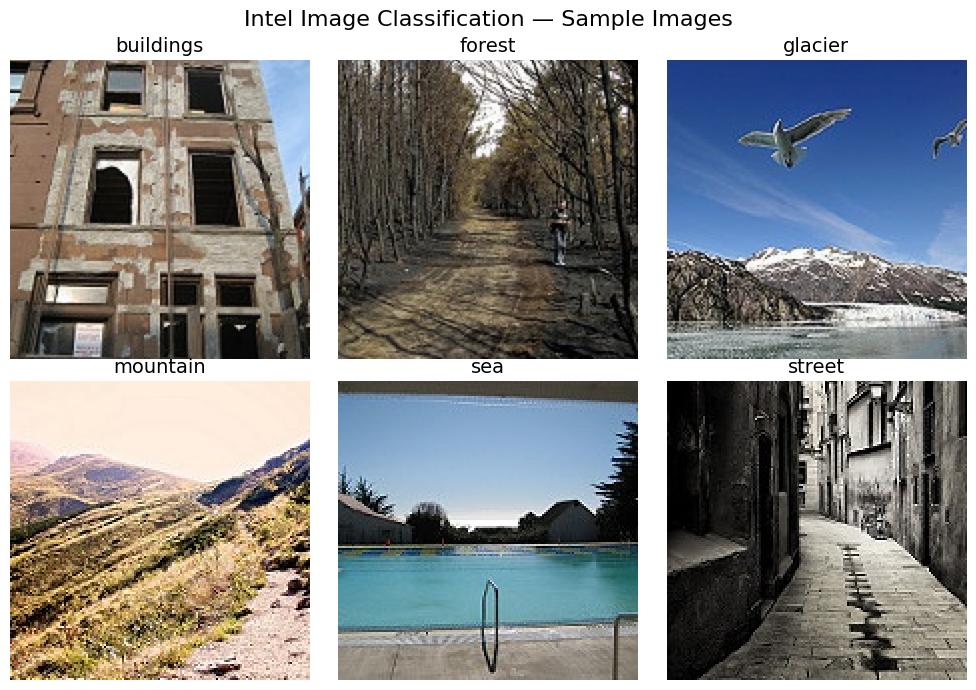

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(10, 7))

for idx, label in enumerate(LABELS):
    img = next(img for img, lbl in image_set if lbl == label)
    
    row, col = idx // 3, idx % 3
    axes[row][col].imshow(img)
    axes[row][col].set_title(label, fontsize=14)
    axes[row][col].axis("off")

plt.suptitle("Intel Image Classification — Sample Images", fontsize=16)
plt.tight_layout()
plt.savefig("outputs/dataset_sample.png")
plt.show()

# The six scene types in this dataset (buildings, forest, glacier, mountain,
# sea, street) do not directly match any ImageNet classes. However, a pretrained
# ImageNet model is still a reasonable starting point, not a poor fit.
#
# ImageNet contains visually similar concepts: "alp" and "valley" share visual
# patterns with "mountain", "lakeside" with "sea", "greenhouse" with "forest".
# The model has already learned to detect edges, textures, and shapes that are
# useful for distinguishing these scenes.
#
# As we saw in inference: sea images scored highest confidence (0.571) because
# ImageNet has many water-related classes. The model "knows" water — it just
# calls it "lakeside" instead of "sea".
#
# This is the core idea of transfer learning: the pretrained features are
# general enough to be useful on new tasks. We only need to replace the final
# layer to map these features to our 6 classes instead of ImageNet's 1000.

### Task 2: Baseline Inference with ResNet18

In [28]:
resnet_weights   = ResNet18_Weights.DEFAULT
resnet           = models.resnet18(weights=resnet_weights).to(device).eval()
resnet_preproc   = resnet_weights.transforms()
imagenet_classes = resnet_weights.meta["categories"]

print(f"ResNet18 parameters: {sum(p.numel() for p in resnet.parameters()):,}")

ResNet18 parameters: 11,689,512


In [30]:
def run_inference(model, preprocess, image, device, class_labels, top_k=5):
    tensor = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(tensor)
    probs = torch.softmax(outputs, dim=1)
    top_probs, top_indices = probs.topk(top_k)
    
    results = []
    for i in range(top_k):
        label = class_labels[top_indices[0][i].item()]
        prob  = top_probs[0][i].item()
        results.append((label, prob))
    return results

In [31]:
resnet_results = []
for img, true_label in image_set:
    preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)
    resnet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"Processed {len(resnet_results)} images.")

Processed 60 images.


In [41]:
import numpy as np

all_probs = [r["top1_prob"] for r in resnet_results]
print(f"Mean confidence (all classes): {np.mean(all_probs):.3f}")
print("\nConfidence by class:")
for label in LABELS:
    probs = [r["top1_prob"] for r in resnet_results if r["true_label"] == label]
    print(f"  {label:12s}: {np.mean(probs):.3f}")

Mean confidence (all classes): 0.419

Confidence by class:
  buildings   : 0.289
  forest      : 0.248
  glacier     : 0.499
  mountain    : 0.556
  sea         : 0.571
  street      : 0.354


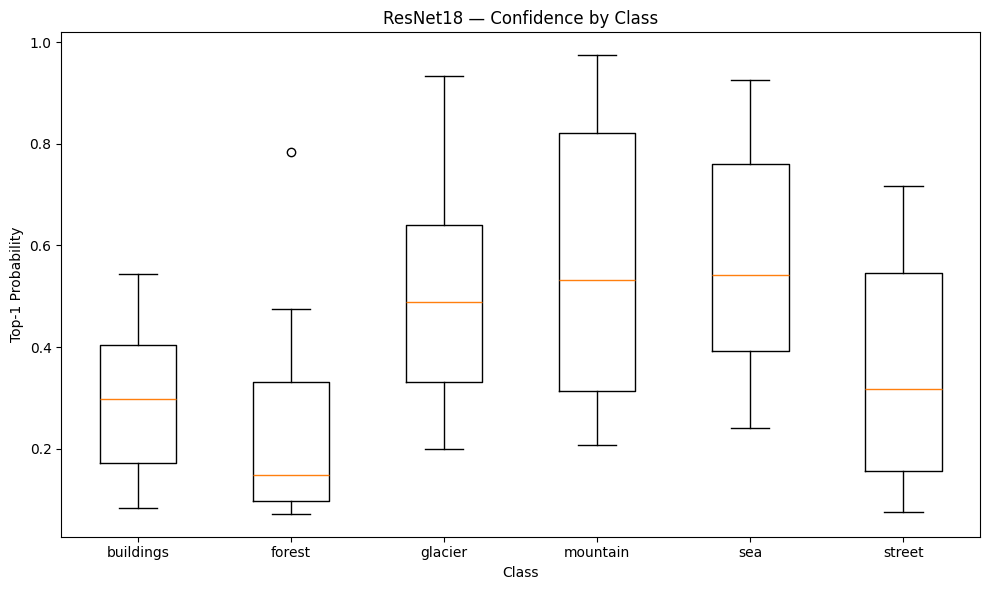

In [43]:
data_by_class = [
    [r["top1_prob"] for r in resnet_results if r["true_label"] == label]
    for label in LABELS
]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(data_by_class, tick_labels=LABELS)
ax.set_title("ResNet18 — Confidence by Class")
ax.set_xlabel("Class")
ax.set_ylabel("Top-1 Probability")
plt.tight_layout()
plt.savefig("outputs/resnet18_confidence_by_class.png")
plt.show()

# High confidence and high accuracy are not the same thing.
# A model can be confidently wrong — for example, our model predicted
# "bell cote" for a buildings image with 54% confidence.
#
# In a production photo tagging pipeline, confidence scores can be used
# as a routing mechanism:
#
#   confidence >= 0.8  → apply tag automatically
#   confidence < 0.8   → send to human reviewer
#
# This threshold of 0.8 is conservative by design. Given that our model
# was trained on ImageNet (not our 6 classes), even high confidence
# predictions may use wrong labels ("monastery" instead of "buildings").
#
# A human reviewer queue handles edge cases without exposing users
# to systematic mislabeling. The threshold can be tuned based on
# the acceptable error rate for the specific application.

### Task 3: Multi-Model Comparison

In [45]:
# MobileNetV3-Small — designed for mobile and edge deployment
mobile_weights = MobileNet_V3_Small_Weights.DEFAULT
mobilenet      = models.mobilenet_v3_small(weights=mobile_weights).to(device).eval()
mobile_preproc = mobile_weights.transforms()

# EfficientNet-B0 — designed to maximize accuracy per unit of compute
effnet_weights = EfficientNet_B0_Weights.DEFAULT
efficientnet   = models.efficientnet_b0(weights=effnet_weights).to(device).eval()
effnet_preproc = effnet_weights.transforms()

# Parameter counts for all three models
for name, m in [("ResNet18",          resnet),
                ("MobileNetV3-Small", mobilenet),
                ("EfficientNet-B0",   efficientnet)]:
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:22s}  {params:>12,} parameters")


# A smaller parameter count implies lower model capacity — the model can
# memorize fewer visual patterns. This usually means lower accuracy on
# complex tasks compared to larger models.
#
# Tradeoffs by deployment target:
#
# Phone (MobileNetV3-Small — 2.5M params):
#   + Fast inference on weak hardware
#   + Low memory usage
#   + Low battery consumption
#   - May miss subtle visual differences
#
# Cloud server (ResNet18 / EfficientNet-B0 — 5-12M params):
#   + Higher accuracy, more visual patterns learned
#   + Hardware is powerful — large models run fast
#   - Would be too slow and battery-draining on a phone
#
# EfficientNet-B0 is the best of both worlds: 5.3M parameters
# but higher accuracy than ResNet18 (11.7M) — more accuracy per parameter.
# This makes it a strong default choice for cloud deployment.

ResNet18                  11,689,512 parameters
MobileNetV3-Small          2,542,856 parameters
EfficientNet-B0            5,288,548 parameters


In [47]:
# MobileNet inference
mobilenet_results = []
for img, true_label in image_set:
    preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes)
    mobilenet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

# EfficientNet inference
effnet_results = []
for img, true_label in image_set:
    preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes)
    effnet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"MobileNet results:   {len(mobilenet_results)}")
print(f"EfficientNet results: {len(effnet_results)}")

MobileNet results:   60
EfficientNet results: 60


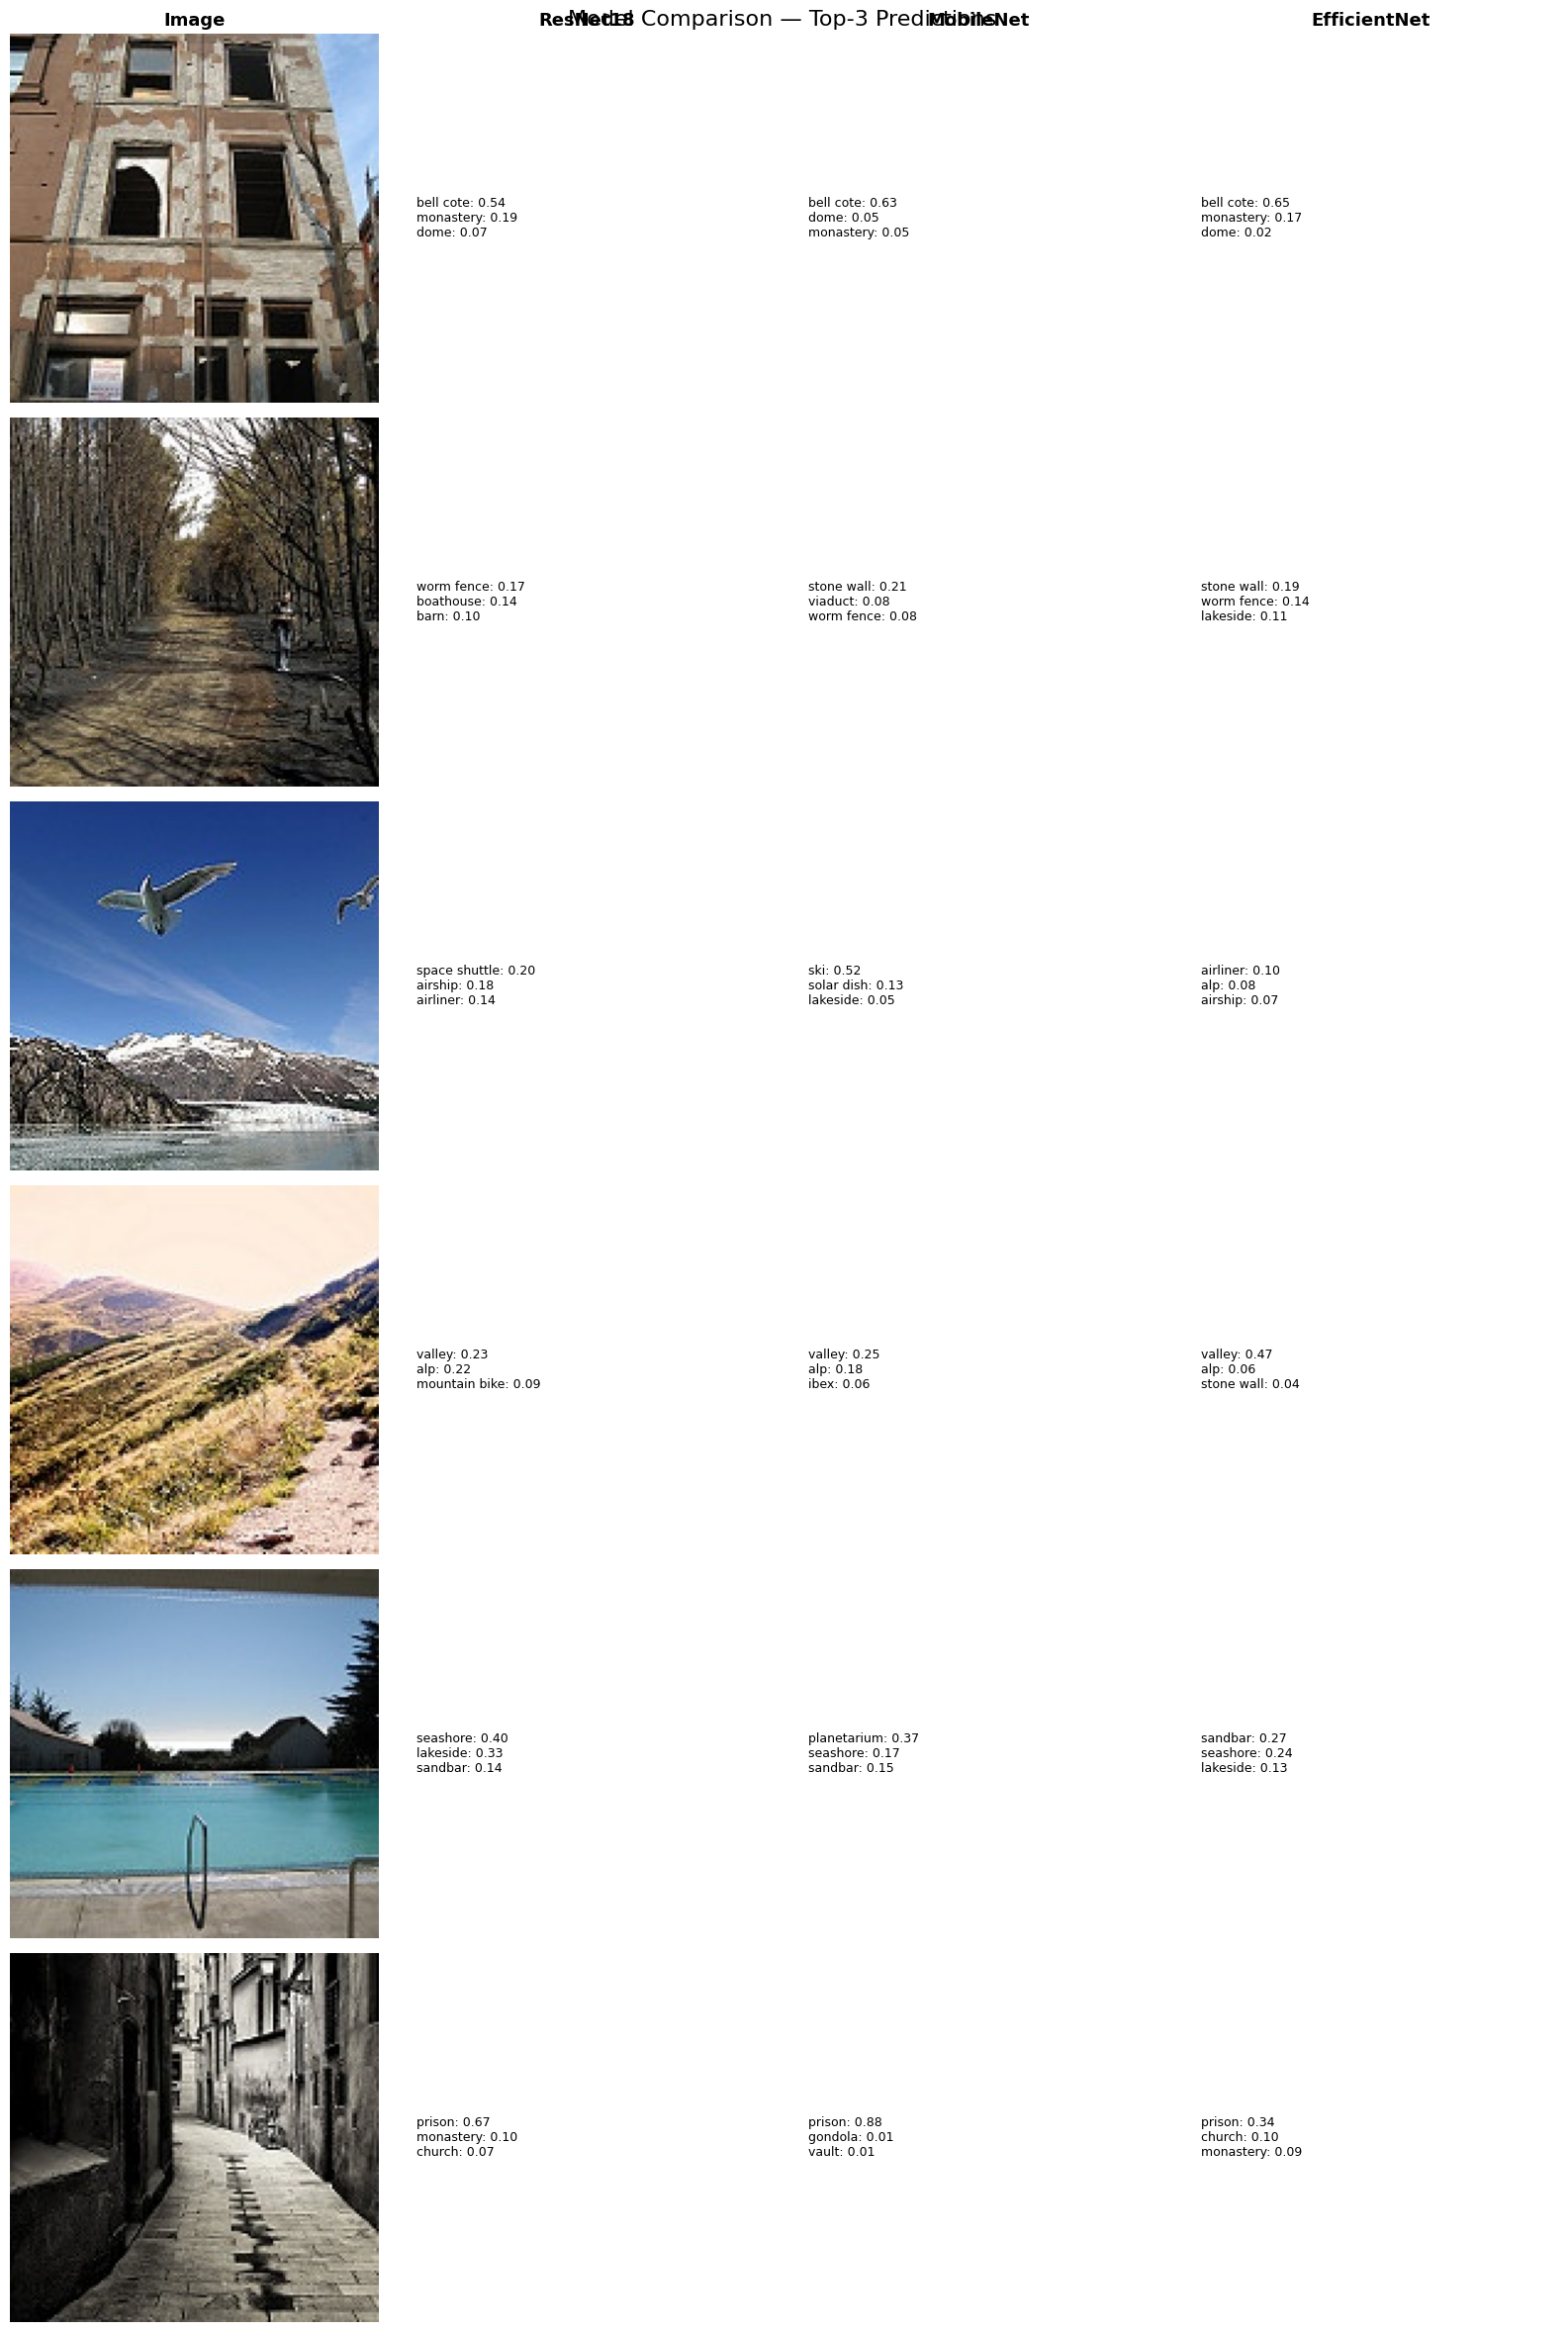

In [48]:
fig, axes = plt.subplots(6, 4, figsize=(16, 24))

col_titles = ["Image", "ResNet18", "MobileNet", "EfficientNet"]
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=13, fontweight="bold")

for row, label in enumerate(LABELS):
  
    idx = next(i for i, (_, lbl) in enumerate(image_set) if lbl == label)
    img = image_set[idx][0]

    axes[row][0].imshow(img)
    axes[row][0].set_ylabel(label, fontsize=12, fontweight="bold")
    axes[row][0].axis("off")

    for col, results in enumerate([resnet_results, mobilenet_results, effnet_results], start=1):
        r = results[idx]
        text = "\n".join([
            f"{r['top5_classes'][i][:20]}: {r['top5_probs'][i]:.2f}"
            for i in range(3)
        ])
        axes[row][col].text(0.05, 0.5, text, fontsize=9,
                           verticalalignment="center",
                           transform=axes[row][col].transAxes)
        axes[row][col].axis("off")

plt.suptitle("Model Comparison — Top-3 Predictions", fontsize=16)
plt.tight_layout()
plt.savefig("outputs/model_comparison_grid.png")
plt.show()

# Do the three models generally agree on their top-1 prediction?
# In 3 out of 6 classes models agreed on top-1, in 2 cases they completely
# disagreed, and in 1 case two models agreed.
#
# Disagreement was most visible on glacier and forest — visually ambiguous
# classes that have no direct ImageNet equivalent. For example, on glacier:
#   ResNet18:     space shuttle (0.20) — semantically wrong
#   MobileNet:    ski (0.52)           — closest to correct
#   EfficientNet: airliner (0.10)      — semantically wrong
#
# When models disagree significantly, an ensemble (majority voting) could help:
# if 2 out of 3 models agree, that prediction is more reliable than any
# single model alone. Disagreement itself is a useful signal — it flags
# uncertain images for human review.
#
# For outdoor scenes, MobileNet produced the most semantically sensible
# top-5 predictions — "ski" for glacier, "valley" for mountain.
# Despite having the fewest parameters, it handled scene-level
# understanding better than ResNet18 on this specific dataset.

### Task 4: Speed vs. Accuracy Tradeoff

In [49]:
def benchmark_model(model, preprocess, image_set, device, n_warmup=5):
    """
    Benchmark single-image inference speed.
    Returns mean latency in milliseconds per image.
    """
    # Warm up the GPU — the first few calls are slower due to CUDA initialization
    for img, _ in image_set[:n_warmup]:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    # Timed run — synchronize before and after to get accurate GPU timing
    torch.cuda.synchronize()
    start = time.time()

    for img, _ in image_set:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    torch.cuda.synchronize()
    elapsed = time.time() - start

    return (elapsed / len(image_set)) * 1000  # milliseconds per image

resnet_ms  = benchmark_model(resnet,       resnet_preproc,  image_set, device)
mobile_ms  = benchmark_model(mobilenet,    mobile_preproc,  image_set, device)
effnet_ms  = benchmark_model(efficientnet, effnet_preproc,  image_set, device)

print(f"ResNet18:           {resnet_ms:.2f} ms/image")
print(f"MobileNetV3-Small:  {mobile_ms:.2f} ms/image")
print(f"EfficientNet-B0:    {effnet_ms:.2f} ms/image")

ResNet18:           4.04 ms/image
MobileNetV3-Small:  6.71 ms/image
EfficientNet-B0:    9.90 ms/image


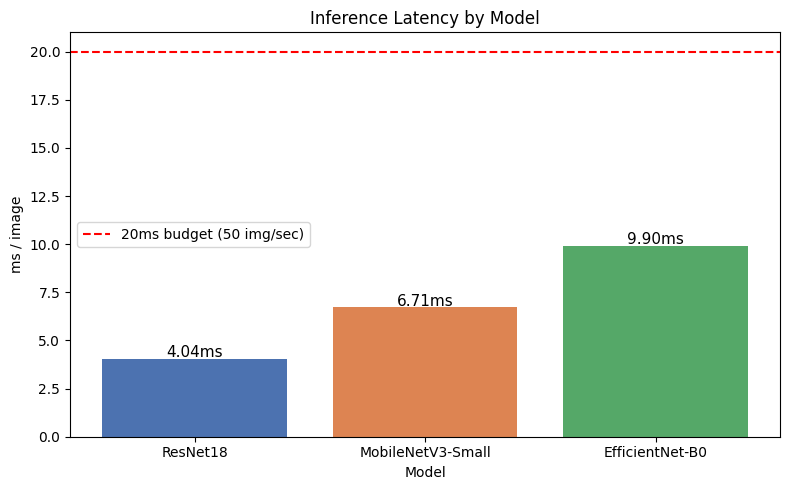

In [50]:
models = ["ResNet18", "MobileNetV3-Small", "EfficientNet-B0"]
times  = [resnet_ms, mobile_ms, effnet_ms]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, times, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_title("Inference Latency by Model")
ax.set_xlabel("Model")
ax.set_ylabel("ms / image")
ax.axhline(y=20, color="red", linestyle="--", label="20ms budget (50 img/sec)")
ax.legend()

for bar, val in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{val:.2f}ms", ha="center", fontsize=11)

plt.tight_layout()
plt.savefig("outputs/inference_speed.png")
plt.show()

In [51]:
print(f"{'Model':22s}  {'Parameters':>12}  {'ms/image':>10}")
print("-" * 48)
print(f"{'ResNet18':22s}  {'11,689,512':>12}  {resnet_ms:>9.2f}")
print(f"{'MobileNetV3-Small':22s}  {'2,542,856':>12}  {mobile_ms:>9.2f}")
print(f"{'EfficientNet-B0':22s}  {'5,288,548':>12}  {effnet_ms:>9.2f}")

# Maximum tolerable latency at 50 images/sec:
# 1000ms / 50 = 20ms per image
#
# All three models meet this requirement:
#   ResNet18:          4.04ms 
#   MobileNetV3-Small: 6.71ms 
#   EfficientNet-B0:   9.90ms 
#
# Deployment recommendations:
#
# (a) High-throughput cloud pipeline → EfficientNet-B0
#     Best accuracy (77.7% ImageNet top-1) at reasonable speed.
#     Hardware is powerful — 9.90ms is well within budget.
#
# (b) On-device mobile app → MobileNetV3-Small
#     Designed specifically for weak hardware and battery constraints.
#     2.5M parameters means low memory footprint on phone RAM.
#     On GPU benchmark it looks slower than ResNet, but on mobile
#     CPU it will outperform larger models significantly.
#
# (c) Safety-critical quality control → EfficientNet-B0
#     Accuracy matters more than speed — wrong predictions have
#     real consequences. EfficientNet gives the best accuracy
#     per parameter. If even higher accuracy is needed,
#     consider fine-tuning on domain-specific data.

Model                     Parameters    ms/image
------------------------------------------------
ResNet18                  11,689,512       4.04
MobileNetV3-Small          2,542,856       6.71
EfficientNet-B0            5,288,548       9.90


### Task 5: Pretrained Features as a Window into Transfer Learning

In [52]:
import copy

feature_extractor = copy.deepcopy(resnet)
feature_extractor.fc = torch.nn.Identity()
feature_extractor    = feature_extractor.to(device).eval()

def extract_features(model, preprocess, image, device):
    tensor   = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        features = model(tensor)
    return features.squeeze().cpu().numpy()

# Extract features for all images
feature_vectors = []
true_labels     = []

for img, label in image_set:
    feat = extract_features(feature_extractor, resnet_preproc, img, device)
    feature_vectors.append(feat)
    true_labels.append(label)

feature_matrix = np.array(feature_vectors)
print(f"Feature matrix shape: {feature_matrix.shape}")

Feature matrix shape: (60, 512)


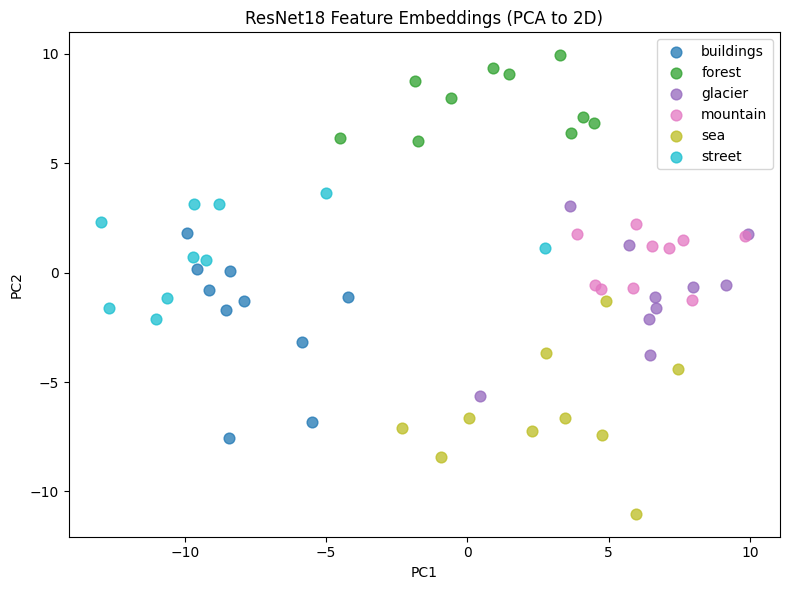

In [53]:
pca          = PCA(n_components=2)
features_2d  = pca.fit_transform(feature_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
colors  = plt.cm.tab10(np.linspace(0, 1, len(LABELS)))

for i, label in enumerate(LABELS):
    mask = [l == label for l in true_labels]
    ax.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        label=label, color=colors[i], s=60, alpha=0.75
    )

ax.legend()
ax.set_title("ResNet18 Feature Embeddings (PCA to 2D)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("outputs/feature_embeddings.png")
plt.show()

# Do images from the same class cluster together in 2D feature space?
# Yes — forest, sea, buildings each form visible clusters even though
# ResNet18 was never trained on these 6 classes.
# This shows the model learned general visual features (textures, colors,
# shapes) that are useful far beyond ImageNet's 1000 categories.
# Glacier and mountain overlap slightly — they share visual patterns
# (snow, rock, sky) which explains model confusion between them.
#
# Feature extraction vs fine-tuning for X-ray classification (500 examples):
#
# Start with FEATURE EXTRACTION:
#   - Freeze all pretrained layers, train only the final layer
#   - 500 examples is too few to retrain millions of weights safely
#   - Pretrained features (edges, textures, shapes) transfer well
#     even to medical images — bones have edges, lungs have textures
#   - Fast to train, low risk of overfitting
#
# Fine-tuning would be the next step only if:
#   - Feature extraction results are not good enough
#   - More labeled data becomes available (thousands, not hundreds)

### Task 6: Summary and Recommendation

In [ ]:
# TASK 6: Summary and Production Recommendation

# 1. Model Comparison
# EfficientNet-B0 performed best overall for this dataset.
# It showed strong confidence on mountain (0.556) and sea (0.571),
# and produced semantically sensible top-5 predictions across classes.
# Despite being slowest (9.90ms), it stays well within the 20ms budget.
# MobileNet surprised with good semantic predictions despite fewest parameters.
# ResNet18 was fastest (4.04ms) but largest (11.7M params) with lower accuracy.

# 2. Confidence Calibration
# ResNet18 was most confident on sea (0.571) and mountain (0.556) —
# these classes have close ImageNet equivalents (lakeside, alp).
# Least confident on forest (0.248) and buildings (0.289) —
# these spread across many ImageNet classes with no direct match.
# This matches intuition: open water and mountain peaks are visually
# distinctive, while forests and buildings vary enormously in appearance.

# 3. Production Recommendation
# For classifying user-uploaded outdoor photos into 6 scene categories:
#
# Recommended model: EfficientNet-B0
# Best accuracy-to-size ratio (77.7% ImageNet top-1, 5.3M params).
# All three models meet the latency budget, so accuracy wins.
#
# Required preprocessing steps:
# - Resize to 256px, CenterCrop to 224px
# - Normalize with ImageNet mean/std [0.485,0.456,0.406] / [0.229,0.224,0.225]
# - Use EfficientNet_B0_Weights.DEFAULT transforms — not a custom pipeline
#
# Key risk before shipping:
# The model outputs ImageNet labels ("alp", "lakeside"), not our 6 classes.
# Without fine-tuning the final layer, predictions will be semantically
# approximate but never exact. A minimum viable fix: fine-tune only the
# final layer on labeled examples of our 6 classes before deployment.